
# Implement/Use the brute force algorithm for the Vertex Cover problem for  n = 10, m = 10, 20, …40. Record the size of the computed vertex cover and the running time for each (n, m) pair.



Step-1 : Here we are generating the input for the no. of vertices=10 and no. of edges=[10,20,30,40]

In [10]:
import random
import networkx as nx
import matplotlib.pyplot as plt

def generate_random_graph(n, m):
    max_edges = n * (n - 1) // 2
    if m > max_edges:
        raise ValueError(f"Too many edges {m} for {n} nodes, max is {max_edges}")

    edges = set()
    while len(edges) < m:
        u = random.randint(0, n - 1)
        v = random.randint(0, n - 1)
        if u != v:
            edge = (min(u, v), max(u, v))
            edges.add(edge)
    return list(edges)

n = 10
m_values = [10, 20, 30, 40]
graphs = {}

for m in m_values:
    graphs[m] = generate_random_graph(n, m)

Step-2 : Here are are storing the the input for every pair of vertices and columns into a csv file.

i.e. ***(n,m)--->(10,10),(10,20),(10,30) and (10,40).***

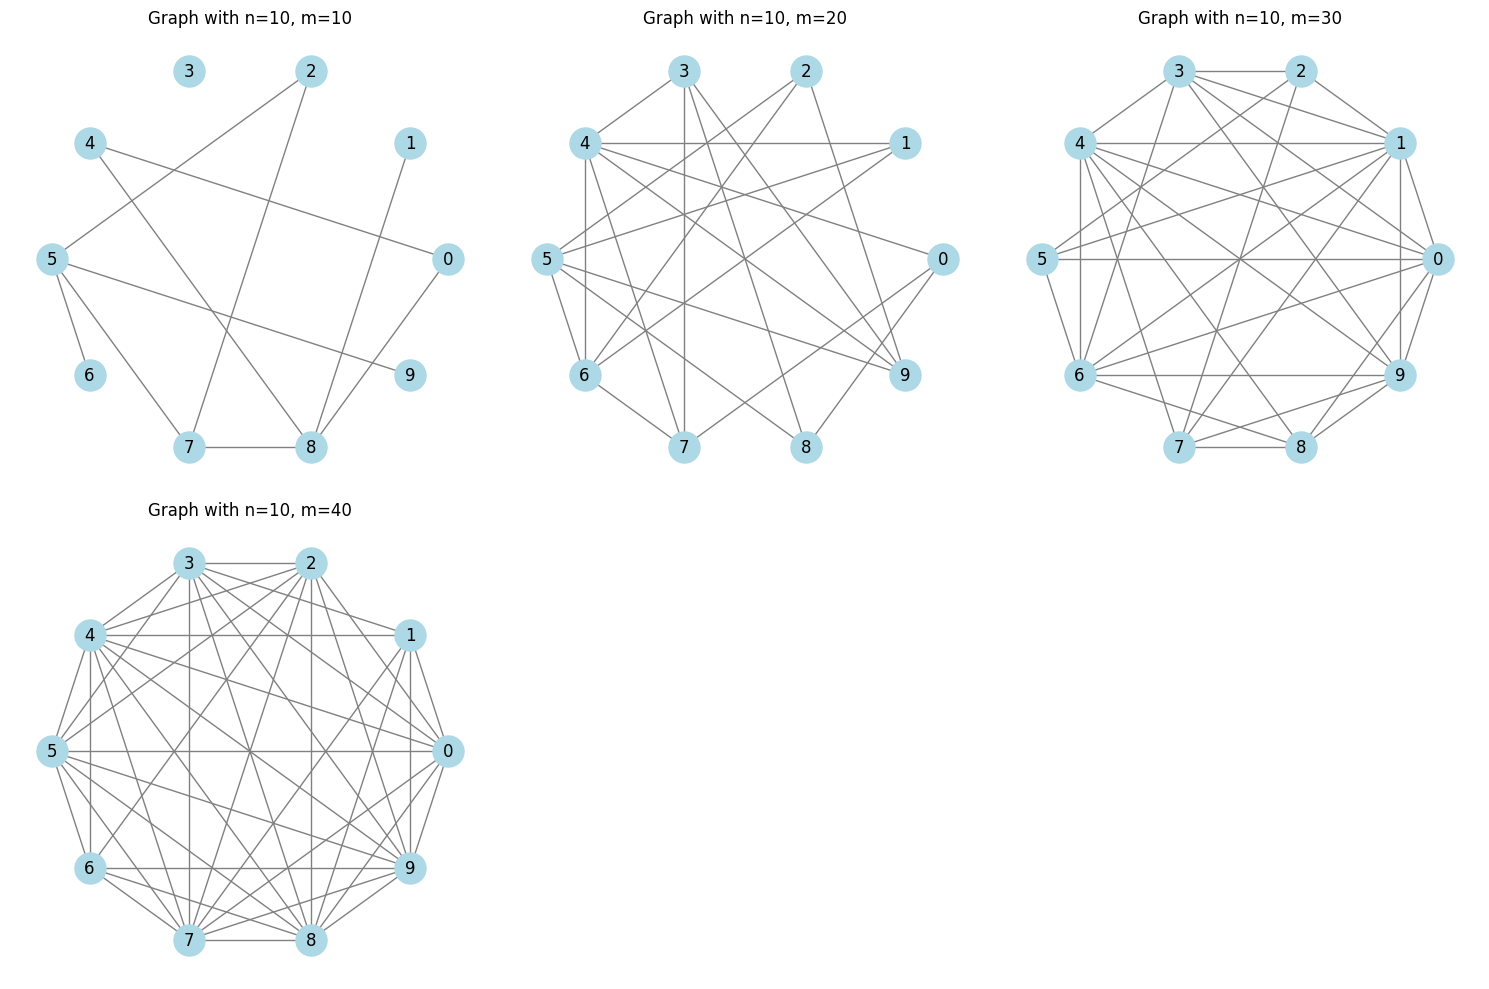

Graph with n=10, m=10 saved to graph_n10_m10.csv
Graph with n=10, m=20 saved to graph_n10_m20.csv
Graph with n=10, m=30 saved to graph_n10_m30.csv
Graph with n=10, m=40 saved to graph_n10_m40.csv


In [9]:
#Taken help from GenAI tool ChatGPT for this.
import csv
# Plotting
plt.figure(figsize=(15, 10))
pos = nx.circular_layout(range(n))  # fixed positions for all graphs

for i, m in enumerate(m_values, 1):
    G = nx.Graph()
    G.add_nodes_from(range(n))
    G.add_edges_from(graphs[m])

    plt.subplot(2, 3, i)
    nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500)
    plt.title(f"Graph with n={n}, m={m}")
    plt.axis('off')

plt.tight_layout()
plt.show()
# After generating each graph in your loop:
for m in m_values:
    edges = graphs[m]
    filename = f"graph_n{n}_m{m}.csv"
    with open(filename, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['node1', 'node2'])  # header
        for u, v in edges:
            writer.writerow([u, v])
    print(f"Graph with n={n}, m={m} saved to {filename}")


Step-4 : Here we are implemeting vertex cover on all the pair of vertices and edges.

**Here we supposed to calculate the cover size and running time.**

In [8]:
#Used GenAI tool ChatGpt for this.
import itertools
import time
import csv
import networkx as nx
import matplotlib.pyplot as plt

def is_vertex_cover(subset, edges):
    subset_set = set(subset)
    for (u, v) in edges:
        if u not in subset_set and v not in subset_set:
            return False
    return True

def brute_force_vertex_cover(n, edges):
    vertices = list(range(n))
    for r in range(1, n + 1):
        for subset in itertools.combinations(vertices, r):
            if is_vertex_cover(subset, edges):
                return subset
    return None  # fallback

n = 10
results = []

# Assuming `graphs` is a dict like {m: [(u,v), (u,v), ...]}
for m, edges in graphs.items():
    start_time = time.time()
    cover = brute_force_vertex_cover(n, edges)
    end_time = time.time()

    cover_size = len(cover)
    running_time = end_time - start_time
    results.append((m, cover_size, running_time))
    print(f"m={m}, vertex cover size={cover_size}, time={running_time:.4f} seconds")

    # --- Save graph edges and minimum vertex cover to CSV ---
    csv_filename = f"graph_n{n}_m{m}_with_cover.csv"
    with open(csv_filename, mode='w', newline='') as file:
        writer = csv.writer(file)
        # Write header
        writer.writerow(['type', 'node1', 'node2'])
        # Write edges with type 'edge'
        for u, v in edges:
            writer.writerow(['edge', u, v])
        # Write vertex cover nodes with type 'cover' (node2 empty)
        for v in cover:
            writer.writerow(['cover', v, ''])
    print(f"Saved graph and cover to {csv_filename}")

    # --- Plot graph with vertex cover highlighted ---
    G = nx.Graph()
    G.add_nodes_from(range(n))
    G.add_edges_from(edges)

    pos = nx.spring_layout(G, seed=42)  # fixed seed for consistency

    node_colors = ['red' if node in cover else 'lightblue' for node in G.nodes()]
    plt.figure(figsize=(6,6))
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=500)
    nx.draw_networkx_edges(G, pos)
    nx.draw_networkx_labels(G, pos)
    plt.title(f"Graph n={n}, m={m}, Vertex Cover size={cover_size}")
    plt.axis('off')

    png_filename = f"graph_n{n}_m{m}_vertex_cover.png"
    plt.savefig(png_filename)
    plt.close()
    print(f"Saved plot to {png_filename}")

# --- Save summary results to a CSV ---
summary_filename = f"vertex_cover_summary.csv"
with open(summary_filename, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['m', 'cover_size', 'time_seconds'])
    for m, cover_size, running_time in results:
        writer.writerow([m, cover_size, f"{running_time:.4f}"])

print(f"\nSummary results saved to {summary_filename}")

# Print summary
print("\nSummary:")
print("m\tCover Size\tTime (seconds)")
for m, cover_size, running_time in results:
    print(f"{m}\t{cover_size}\t\t{running_time:.4f}")


m=10, vertex cover size=4, time=0.0001 seconds
Saved graph and cover to graph_n10_m10_with_cover.csv
Saved plot to graph_n10_m10_vertex_cover.png
m=20, vertex cover size=6, time=0.0004 seconds
Saved graph and cover to graph_n10_m20_with_cover.csv
Saved plot to graph_n10_m20_vertex_cover.png
m=30, vertex cover size=7, time=0.0005 seconds
Saved graph and cover to graph_n10_m30_with_cover.csv
Saved plot to graph_n10_m30_vertex_cover.png
m=40, vertex cover size=8, time=0.0006 seconds
Saved graph and cover to graph_n10_m40_with_cover.csv
Saved plot to graph_n10_m40_vertex_cover.png

Summary results saved to vertex_cover_summary.csv

Summary:
m	Cover Size	Time (seconds)
10	4		0.0001
20	6		0.0004
30	7		0.0005
40	8		0.0006
